June 1
Michael added the pi charts and we discussed possible changes to the model, in particular, Michael researched the use of concatenating with another foundation model, but we decided against it.

In [1]:
import numpy as np
import pandas as pd
import torch
# import gc
from sklearn.manifold import TSNE
from sklearn import metrics
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# #for google colab only
# !pip install fair-esm

In [ ]:
# load the dataframes
train_df_mean = pd.read_csv("../processed_data/all_deeploc_data_mean_pooling.csv")
#print(train_df_mean)


448.0


/var/folders/59/182g9wh9085dxqn7ptw0xhmh0000gn/T/ipykernel_37914/25057544.py:2: DtypeWarning: Columns (0: emb_339) have mixed types. Specify dtype option on import or set low_memory=False.
  train_df_mean = pd.read_csv("../processed_data/all_deeploc_data_mean_pooling.csv")


In [3]:
locations = ['Membrane', 'Cytoplasm', 'Nucleus', 'Extracellular', 'Cell membrane',
             'Mitochondrion', 'Plastid', 'Endoplasmic reticulum', 'Lysosome/Vacuole',
             'Golgi apparatus', 'Peroxisome']

LOCATIONS = locations

In [9]:
# generate train/dev split - classic 80/20 split with random set to a seed for comparability
from sklearn.model_selection import train_test_split


def get_train_dev_sets(train_df_mean, dev_set_partition_number):
    """function for pooling the train and dev set + weights. dev_set_partition_number=cross validation parameter"""

    y_train_mean = train_df_mean[LOCATIONS][train_df_mean['Partition'] != dev_set_partition_number]
    balancing_weights = y_train_mean.shape[0]/y_train_mean.sum(axis=0)
    # make the x_train_df_mean - could use a list comprehension or use the pandas series functions
    # however, its more efficient to make a boolean array
    selected_cols_mean = train_df_mean.columns[train_df_mean.columns.str.startswith('emb_')]
    x_train_mean = train_df_mean.loc[:, selected_cols_mean][train_df_mean['Partition'] != dev_set_partition_number]

    # partition the data
    x_dev_mean = train_df_mean.loc[:, selected_cols_mean][train_df_mean['Partition'] == dev_set_partition_number]
    y_dev_mean = train_df_mean[LOCATIONS][train_df_mean['Partition'] == dev_set_partition_number]

    # load the batches and make the model for mean
    x_train_mean_tensor = torch.tensor(x_train_mean.values, dtype=torch.float32) # 32 is standard for pytorch
    y_train_mean_tensor = torch.tensor(y_train_mean.values, dtype=torch.float32)
    train_dataset_mean = TensorDataset(x_train_mean_tensor, y_train_mean_tensor)
    train_loader_mean = DataLoader(train_dataset_mean, batch_size=64, shuffle=True)

    # make dev tensors
    x_dev_mean_tensor = torch.tensor(x_dev_mean.values, dtype=torch.float32)
    y_dev_mean_tensor = torch.tensor(y_dev_mean.values, dtype=torch.float32)

    return x_train_mean_tensor, y_train_mean_tensor, train_dataset_mean, train_loader_mean, x_dev_mean_tensor, y_dev_mean_tensor, balancing_weights
get_train_dev_sets(train_df_mean, 1)

TypeError: can't convert np.ndarray of type numpy.object_. The only supported types are: float64, float32, float16, complex64, complex128, int64, int32, int16, int8, uint64, uint32, uint16, uint8, and bool.

In [6]:
# make the model - single linear layer - logistic regression with BCE loss

class LogisticRegression(nn.Module):
    
    def __init__(self, input_size, num_logits):
        # call to the __init__ function of the super class
        super().__init__()

        # Bookkeeping: Sacing the initialization parameters
        self.input_size = input_size
        self.num_logits = num_logits

        # Defining the model
        self.model = nn.Sequential(
            nn.Linear(self.input_size, self.num_logits)
        )

    def forward(self, x):
        logits = self.model(x)
        return logits
    

In [7]:
import torch.optim as optim
from sklearn.metrics import (matthews_corrcoef, f1_score,
                             hamming_loss, jaccard_score)

# train the model
def train_model(model, loader, criterion, optimizer, x_dev_tensor, y_dev_tensor, num_epochs):
    # initialize the lists
    train_loss_lst = []
    dev_loss_lst = []
    # go through the training epochs
    for epoch in range(num_epochs):
        train_loss = 0.0
        # configure the model for training
        model.train()
        for batch in loader:
            inputs, labels = batch
            optimizer.zero_grad()
            logits = model(inputs)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * inputs.size(0)
        train_loss /= len(loader.dataset)
        train_loss_lst.append(train_loss)
        
        # evaluate the dev set
        model.eval()
        with torch.no_grad():
            logits_dev = model(x_dev_tensor)
            loss_dev = criterion(logits_dev, y_dev_tensor)
            dev_loss_lst.append(loss_dev.item())
        # print the progress
        if epoch % 40 == 0 or epoch == num_epochs - 1:
            print(f"Epoch {epoch+1}/{num_epochs}, Train Loss {train_loss:.4f}, Dev Loss {loss_dev.item():.4f}")
    # print("Training Complete!")
    return train_loss_lst, dev_loss_lst

def plot_losses(train_loss_lst, dev_loss_lst, n_epochs, experiment_title):
    plt.figure(figsize=(8, 4))
    plt.plot(range(1, n_epochs + 1), train_loss_lst, label='train')
    plt.plot(range(1, n_epochs + 1), dev_loss_lst,   label='dev')
    plt.xlabel('Epoch')
    plt.ylabel('Avg BCE Loss')
    plt.title(f"Training vs. Dev Loss for {experiment_title}")
    plt.legend()
    plt.tight_layout()
    plt.show()
    return

def run_experiment(x_train, y_train, train_loader, x_dev, y_dev, criterion, experiment_title, num_epochs):
    model = LogisticRegression(x_train.shape[1], y_train.shape[1])
    # do the weights need to match the fundamental data imbalance or the imbalance per the batch?
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    train_loss_lst, dev_loss_lst = train_model(model, train_loader, criterion, optimizer, x_dev, y_dev, num_epochs)

    # graph the losses
    plot_losses(train_loss_lst, dev_loss_lst, num_epochs, experiment_title=experiment_title)
    return model


# all thresholds set to 0.5
def compute_accuracy(model, X_dev, Y_dev, locations):
    # make predictions on dev set
    model.eval()
    with torch.no_grad():
        probs = torch.sigmoid(model(X_dev))
        preds = (probs > 0.5).float()

    y_np = Y_dev.numpy().astype(int)
    p_np = preds.numpy().astype(int)

    # overall metrics (adapted from deeploc2 calculate_sl_metrics_fold)
    acc_exact = (np.all(p_np == y_np, axis=1)).mean()          # all 11 labels correct
    jaccard = jaccard_score(y_np, p_np, average='samples')   # intersection/union per protein
    micro_f1 = f1_score(y_np, p_np, average='micro', zero_division=0)
    macro_f1 = f1_score(y_np, p_np, average='macro', zero_division=0)

    model_accs = [acc_exact, jaccard, micro_f1, macro_f1]
    
    class_mccs = []
    for i, loc in enumerate(locations):
        class_acc = (p_np[:, i] == y_np[:, i]).mean()
        class_mcc = matthews_corrcoef(y_np[:, i], p_np[:, i])
        class_mccs.append(class_mcc)
        #print(f"{loc:<25} {class_acc:>10.4f} {class_mcc:>10.4f}")
    return (model_accs, class_mccs)


In [10]:
def plot_prediction_pies(truth_data, predicted_data, graph_name):
    diff = truth_data - predicted_data  # (2211, 11)

    has_pos  = (diff ==  1).any(dim=1)  # underpredicted at least one label
    has_neg  = (diff == -1).any(dim=1)  # overpredicted at least one label

    exact        = (~has_pos & ~has_neg).sum().item()
    underpredict = ( has_pos & ~has_neg).sum().item()
    overpredict  = (~has_pos &  has_neg).sum().item()
    both         = ( has_pos &  has_neg).sum().item()

    labels = ['Exact match', 'Underprediction', 'Overprediction', 'Wrong both directions']
    sizes  = [exact, underpredict, overpredict, both]

    fig, ax = plt.subplots()
    ax.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)
    ax.set_title(f'Prediction error categories for {graph_name}')
    plt.show()


    fig, axes = plt.subplots(nrows=2, ncols=6, figsize=(18, 7))
    axes = axes.flatten()

    labels = ['TP', 'FN', 'FP'] #truth, missed, false prediction
    colors = ["#5590D9", "#FF8C00", "#D94040"]

    for i, loc in enumerate(LOCATIONS):
        t = truth_data[:, i]
        p = predicted_data[:, i]

        tp = ((t == 1) & (p == 1)).sum().item()
        fn = ((t == 1) & (p == 0)).sum().item()
        fp = ((t == 0) & (p == 1)).sum().item()

        sizes = [tp, fn, fp]
        axes[i].pie(sizes, labels=labels, autopct='%1.1f%%', colors=colors, startangle=90)
        axes[i].set_title(f"{loc} \n n = { tp+fn+fp} ", fontsize=15)

    axes[-1].set_visible(False)
    fig.suptitle(f'TP / FN / FP breakdown per location for {graph_name}', fontsize=25)
    plt.tight_layout()
    plt.show()


In [8]:
# RUN cross-validation

lst_to_store_info = []
for dev_partition in range(5):
    #get the relevant dev set dev_partition (e.g. if dev_partition is 0 then partition zero is dev and 1-4 partitions go to train)
    x_train_mean_tensor, y_train_mean_tensor, train_dataset_mean, train_loader_mean, x_dev_mean_tensor, y_dev_mean_tensor, balancing_weights = get_train_dev_sets(train_df_mean, dev_partition)

    #run experiment of interest

    # experiment 1: same as michael - control with no reweighting on mean - 100 epochs
    criterion_1 = nn.BCEWithLogitsLoss()
    reg_model_mean = run_experiment(x_train_mean_tensor, y_train_mean_tensor, train_loader_mean, x_dev_mean_tensor, y_dev_mean_tensor, criterion_1, experiment_title="Mean Embeddings no Weights - 100 Epochs", num_epochs=100)
    lst_to_store_info.append(compute_accuracy(reg_model_mean, x_dev_mean_tensor, y_dev_mean_tensor, locations))


TypeError: can't convert np.ndarray of type numpy.object_. The only supported types are: float64, float32, float16, complex64, complex128, int64, int32, int16, int8, uint64, uint32, uint16, uint8, and bool.

In [17]:
lst_to_store_info_for_simplest_model = lst_to_store_info

In [18]:
reg_model_mean.eval()
with torch.no_grad():
    probs = torch.sigmoid(reg_model_mean(x_dev_mean_tensor))
    preds = (probs > 0.5).float()
preds

tensor([[0., 0., 1.,  ..., 0., 0., 0.],
        [0., 0., 1.,  ..., 0., 0., 0.],
        [0., 1., 1.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 1.,  ..., 0., 0., 0.],
        [0., 0., 1.,  ..., 0., 0., 0.],
        [0., 1., 0.,  ..., 0., 0., 0.]])

reg_model_mean.eval()
with torch.no_grad():
    probs = torch.sigmoid(reg_model_mean(x_dev_mean_tensor))
    preds_mean_pooling = (probs > 0.5).float()
graph_name = "mean_pooling, no weights"
plot_prediction_pies(y_dev_mean_tensor, preds_mean_pooling, graph_name)

Epoch 1/100, Train Loss 9.9869, Dev Loss 7.1997
Epoch 41/100, Train Loss 2.2147, Dev Loss 2.7300
Epoch 81/100, Train Loss 1.9636, Dev Loss 2.5219
Epoch 100/100, Train Loss 1.8936, Dev Loss 2.4698


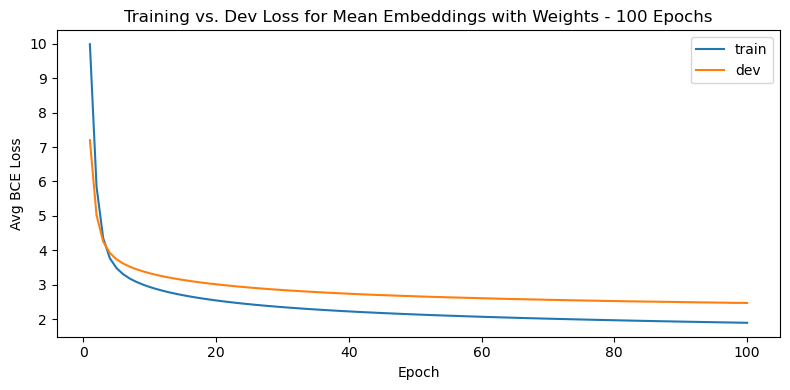

Epoch 1/100, Train Loss 10.7612, Dev Loss 8.0797
Epoch 41/100, Train Loss 2.2824, Dev Loss 2.3340
Epoch 81/100, Train Loss 2.0209, Dev Loss 2.1175
Epoch 100/100, Train Loss 1.9505, Dev Loss 2.0649


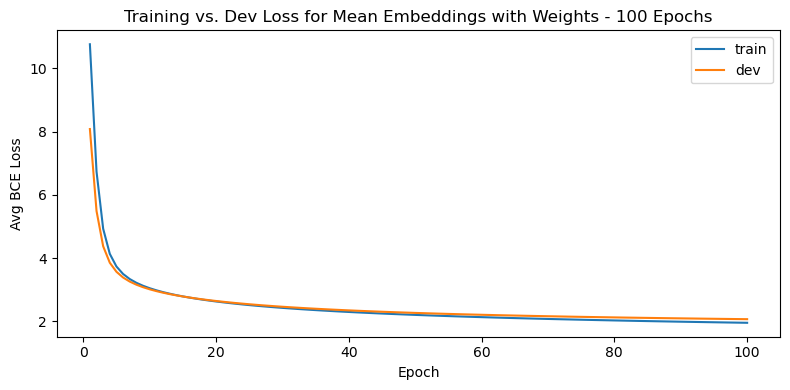

Epoch 1/100, Train Loss 9.7393, Dev Loss 7.3097
Epoch 41/100, Train Loss 2.2854, Dev Loss 2.1693
Epoch 81/100, Train Loss 2.0193, Dev Loss 1.9465
Epoch 100/100, Train Loss 1.9472, Dev Loss 1.8934


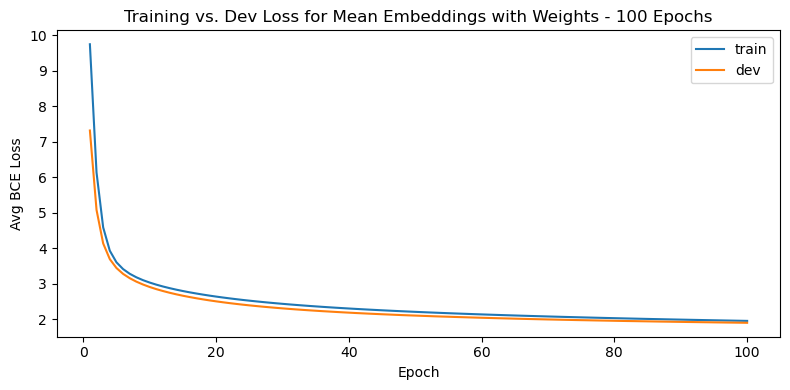

Epoch 1/100, Train Loss 9.8363, Dev Loss 7.0064
Epoch 41/100, Train Loss 2.2055, Dev Loss 2.2593
Epoch 81/100, Train Loss 1.9527, Dev Loss 2.0672
Epoch 100/100, Train Loss 1.8827, Dev Loss 2.0239


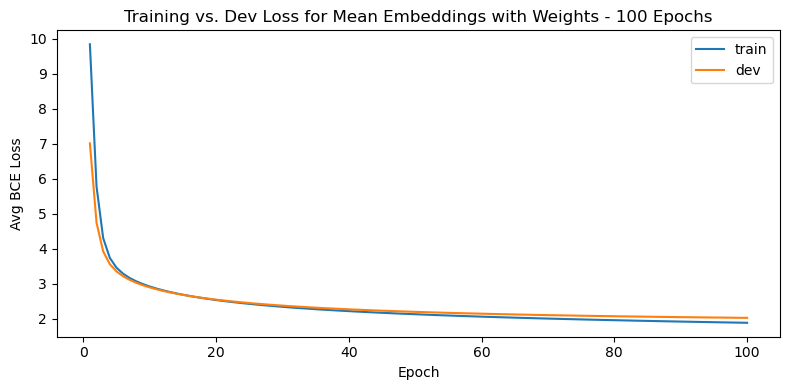

Epoch 1/100, Train Loss 10.3873, Dev Loss 7.2799
Epoch 41/100, Train Loss 2.2155, Dev Loss 2.0802
Epoch 81/100, Train Loss 1.9672, Dev Loss 1.8615
Epoch 100/100, Train Loss 1.8987, Dev Loss 1.8089


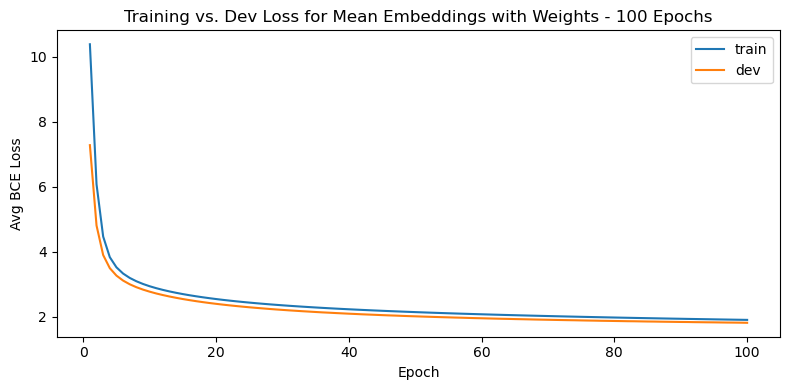

In [ ]:
lst_to_store_info_exp_3 = []
for dev_partition in range(5):
    #get the relevant dev set dev_partition (e.g. if dev_partition is 0 then partition zero is dev and 1-4 partitions go to train)
    x_train_mean_tensor, y_train_mean_tensor, train_dataset_mean, train_loader_mean, x_dev_mean_tensor, y_dev_mean_tensor, balancing_weights = get_train_dev_sets(train_df_mean, dev_partition)

    #run experiment of interest
    # experiment 3: reweighting on mean - 100 epochs
    criterion_3 = nn.BCEWithLogitsLoss(weight=torch.tensor(balancing_weights.values, dtype=torch.float32))
    train_loader_mean = DataLoader(train_dataset_mean, batch_size=2048, shuffle=True)
    reweighting_model_mean = run_experiment(x_train_mean_tensor, y_train_mean_tensor, train_loader_mean, x_dev_mean_tensor, y_dev_mean_tensor, criterion_3,  experiment_title="Mean Embeddings with Weights - 100 Epochs", num_epochs=100)
    lst_to_store_info_exp_3.append(compute_accuracy(reweighting_model_mean, x_dev_mean_tensor, y_dev_mean_tensor, locations))

In [ ]:
reweighting_model_mean.eval()
with torch.no_grad():
    probs = torch.sigmoid(reg_model_mean(x_dev_mean_tensor))
    preds_mean_weight_pooling = (probs > 0.5).float()
graph_name = "mean_pooling, reweighted"
plot_prediction_pies(y_dev_mean_tensor, preds_mean_weight_pooling, graph_name)


In [ ]:
# experiment 6: pos-reweighting (different than regular reweighting) on mean - 100 epochs
criterion_6 = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(balancing_weights.values, dtype=torch.float32))
pos_reweighting_model_mean = run_experiment(x_train_mean_tensor, y_train_mean_tensor, train_loader_mean, x_dev_mean_tensor, y_dev_mean_tensor, criterion_6,  experiment_title="Mean Embeddings with Pos-Weights - 100 Epochs", num_epochs=100)
compute_accuracy(pos_reweighting_model_mean, x_dev_mean_tensor, y_dev_mean_tensor, locations)

In [ ]:
# experiment 7: baseline nonsense data

# make nonsense data by shuffling the labels
y_dev_mean_tensor_shuffled = y_dev_mean_tensor[torch.randperm(y_dev_mean_tensor.size(0))]

# compute accuracy of the original model on the shuffled labels as a sanity check - should be very low
compute_accuracy(reg_model_mean, x_dev_mean_tensor, y_dev_mean_tensor_shuffled, locations)

In [ ]:
# experiment 9: investigate focal loss - mean - 100 epochs
import torchvision

def focal_loss(logits, y_train):
    return torchvision.ops.sigmoid_focal_loss(logits, y_train, reduction='mean')
criterion_9 = focal_loss
reweighting_model_mean = run_experiment(x_train_mean_tensor, y_train_mean_tensor, train_loader_mean, x_dev_mean_tensor, y_dev_mean_tensor, criterion_9,  experiment_title="Mean Embeddings with focal loss", num_epochs=100)
compute_accuracy(reweighting_model_mean, x_dev_mean_tensor, y_dev_mean_tensor, locations)

In [ ]:
# table for cross validation for the logistic regression models
lst_to_store_info_for_simplest_model
lst_to_store_info_